In [6]:
import os
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image

In [7]:
class ACGANGenerator(nn.Module):
    def __init__(self, latent_dim, num_classes, img_channels):
        super(ACGANGenerator, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.img_channels = img_channels
        
        # Input: latent_dim + num_classes
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 128),
            nn.BatchNorm1d(128, 0.8),
            nn.ReLU(inplace=True),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256, 0.8),
            nn.ReLU(inplace=True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512, 0.8),
            nn.ReLU(inplace=True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024, 0.8),
            nn.ReLU(inplace=True),
            nn.Linear(1024, img_channels * 64 * 64),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        # Concatenate noise and labels
        label_input = self.label_emb(labels)
        gen_input = torch.cat((noise, label_input), -1)
        img = self.model(gen_input)
        img = img.view(img.size(0), self.img_channels, 64, 64)
        return img


In [8]:
class ACGANDiscriminator(nn.Module):
    def __init__(self, img_channels, num_classes):
        super(ACGANDiscriminator, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(img_channels * 64 * 64, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2, inplace=True)
        )
        
        # Output layers
        self.adv_layer = nn.Sequential(nn.Linear(128, 1), nn.Sigmoid())
        self.aux_layer = nn.Sequential(nn.Linear(128, num_classes), nn.Softmax(dim=1))

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        features = self.model(img_flat)
        
        # Discriminator output: real/fake
        validity = self.adv_layer(features)
        
        # Auxiliary output: class labels
        label = self.aux_layer(features)

        return validity, label


In [9]:
# Hyperparameters
latent_dim = 100
num_classes = 6
img_channels = 3
learning_rate = 0.0002
batch_size = 76

# Initialize generator and discriminator
generator = ACGANGenerator(latent_dim, num_classes, img_channels)
discriminator = ACGANDiscriminator(img_channels, num_classes)

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=learning_rate, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999))

# Loss functions
adversarial_loss = nn.BCELoss()
auxiliary_loss = nn.CrossEntropyLoss()

In [10]:
# Define the custom dataset to load and preprocess images
class CustomImageDataset(torch.utils.data.Dataset):
    def __init__(self, base_dir, subfolders, transform=None):
        self.base_dir = base_dir
        self.subfolders = subfolders
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        for subfolder in subfolders:
            folder_path = os.path.join(base_dir, subfolder)
            label = subfolder

            for img_name in os.listdir(folder_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(folder_path, img_name)
                    self.image_paths.append(img_path)
                    self.labels.append(label)
        
        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(self.labels)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        label = self.labels[idx]
        return image, label

# Define the base directory and subfolders
base_dir = r'DIAT-uSAT_dataset'
subfolders = [
    r"3_long_blade_rotor", 
    r"3_short_blade_rotor", 
    r"Bird", 
    r"Bird+mini-helicopter", 
    r"drone", 
    r"rc_plane", 
]

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Normalize images to [-1, 1]
])


In [11]:
# Load dataset
dataset = CustomImageDataset(base_dir, subfolders, transform=transform)
dataloader = DataLoader(dataset, batch_size=76, shuffle=True)


In [13]:
import torch

# Initialize best generator and discriminator loss
best_g_loss = float('inf')  # Best generator loss
best_d_loss = float('inf')  # Best discriminator loss

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move models to the correct device (CPU or GPU)
generator.to(device)
discriminator.to(device)

# Number of epochs
num_epochs = 1

# Training loop
for epoch in range(num_epochs):
    total_g_loss = 0.0
    total_d_loss = 0.0
    num_batches = len(dataloader)
    
    for i, (imgs, labels) in enumerate(dataloader):
        batch_size = imgs.size(0)
        
        # Move images and labels to the correct device
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        # Create labels for real and fake data
        valid = torch.ones((batch_size, 1), requires_grad=False).to(device)
        fake = torch.zeros((batch_size, 1), requires_grad=False).to(device)

        # -----------------
        #  Train Generator
        # -----------------
        optimizer_G.zero_grad()

        # Generate random noise and labels for generator input
        z = torch.randn(batch_size, latent_dim).to(device)
        gen_labels = torch.randint(0, num_classes, (batch_size,)).to(device)

        # Generate images using the generator
        gen_imgs = generator(z, gen_labels)
        
        # Get predictions from the discriminator for fake images
        validity, pred_label = discriminator(gen_imgs)

        # Calculate generator loss (adversarial + auxiliary loss)
        g_loss = 0.5 * (adversarial_loss(validity, valid) + auxiliary_loss(pred_label, gen_labels))
        
        # Backpropagate and update generator weights
        g_loss.backward()
        optimizer_G.step()

        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        # Train on real images
        real_pred, real_aux = discriminator(imgs)
        d_real_loss = 0.5 * (adversarial_loss(real_pred, valid) + auxiliary_loss(real_aux, labels))

        # Train on fake images (generated by the generator)
        fake_pred, fake_aux = discriminator(gen_imgs.detach())
        d_fake_loss = 0.5 * (adversarial_loss(fake_pred, fake) + auxiliary_loss(fake_aux, gen_labels))

        # Total discriminator loss (average of real and fake loss)
        d_loss = (d_real_loss + d_fake_loss) / 2
        
        # Backpropagate and update discriminator weights
        d_loss.backward()
        optimizer_D.step()

        # Accumulate losses
        total_g_loss += g_loss.item()
        total_d_loss += d_loss.item()

    # Calculate average losses for the epoch
    avg_g_loss = total_g_loss / num_batches
    avg_d_loss = total_d_loss / num_batches

    # Print the average losses per epoch
    print(f"[Epoch {epoch+1}/{num_epochs}] [D loss: {avg_d_loss:.4f}] [G loss: {avg_g_loss:.4f}]")

    # Save the generator if the current epoch's generator loss is the lowest
    if avg_g_loss < best_g_loss:
        best_g_loss = avg_g_loss
        torch.save(generator.state_dict(), "best_generator_model.pt")  # Save best generator

    # Save the discriminator if the current epoch's discriminator loss is the lowest
    if avg_d_loss < best_d_loss:
        best_d_loss = avg_d_loss
        torch.save(discriminator.state_dict(), "best_discriminator_model.pt")  # Save best discriminator


[Epoch 1/1] [D loss: 0.9603] [G loss: 1.2286]


Generator is on device: cpu
Noise is on device: cpu
Labels are on device: cpu
Generated images shape: torch.Size([6, 3, 64, 64])
Grid shape: torch.Size([3, 68, 398])


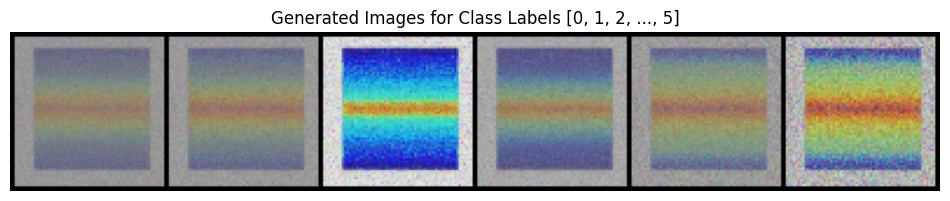

In [14]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

def test_generator(generator, num_classes, latent_dim, device):
    # Set the generator to evaluation mode
    generator.eval()
    
    # Generate random noise and class labels
    z = torch.randn(num_classes, latent_dim).to(device)  # Generate noise
    labels = torch.arange(num_classes).to(device)  # Class labels [0, 1, 2, ..., num_classes-1]
    
    # Move the generator to the specified device (if it's not already there)
    generator = generator.to(device)
    
    # Debugging: Check the device
    print(f"Generator is on device: {next(generator.parameters()).device}")
    print(f"Noise is on device: {z.device}")
    print(f"Labels are on device: {labels.device}")
    
    # Generate images
    with torch.no_grad():  # No need to compute gradients during testing
        gen_imgs = generator(z, labels)
    
    # Debugging: Print shape of generated images
    print(f"Generated images shape: {gen_imgs.shape}")
    
    # Unnormalize the images from [-1, 1] back to [0, 1] for visualization
    gen_imgs = (gen_imgs + 1) / 2.0
    
    # Create a grid of images and display them
    grid = make_grid(gen_imgs.cpu(), nrow=num_classes, normalize=False)
    
    # Debugging: Check grid shape
    print(f"Grid shape: {grid.shape}")
    
    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(f"Generated Images for Class Labels [0, 1, 2, ..., {num_classes-1}]")
    plt.axis("off")
    plt.show()

# Example usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_generator(generator, num_classes=6, latent_dim=100, device=device)

In [15]:
import torch

def test_discriminator(discriminator, generator, dataloader, num_classes, latent_dim, device):
    # Set the models to evaluation mode
    discriminator = discriminator.to(device)  # Move discriminator to the correct device
    generator = generator.to(device)  # Move generator to the correct device
    
    discriminator.eval()
    generator.eval()

    # Initialize lists to store accuracy for real and fake images
    real_accuracy = 0
    fake_accuracy = 0
    class_accuracy = 0
    total_samples = 0

    with torch.no_grad():
        for imgs, labels in dataloader:
            batch_size = imgs.size(0)
            total_samples += batch_size

            imgs = imgs.to(device)
            labels = labels.to(device)
            real_pred, real_aux = discriminator(imgs)
            real_accuracy += (real_pred > 0.5).float().mean().item()  # Binary classification for real/fake
            class_accuracy += (real_aux.argmax(dim=1) == labels).float().mean().item()  # Class accuracy

            # Fake images
            z = torch.randn(batch_size, latent_dim).to(device)
            gen_labels = torch.randint(0, num_classes, (batch_size,)).to(device)
            gen_imgs = generator(z, gen_labels)

            fake_pred, fake_aux = discriminator(gen_imgs)
            fake_accuracy += (fake_pred < 0.5).float().mean().item()  # Fake should be classified as 0 (fake)
            class_accuracy += (fake_aux.argmax(dim=1) == gen_labels).float().mean().item()

    # Calculate average accuracies
    real_accuracy /= len(dataloader)
    fake_accuracy /= len(dataloader)
    class_accuracy /= (2 * len(dataloader))  # Since class accuracy is measured for both real and fake

    print(f"Discriminator Real Accuracy: {real_accuracy * 100:.2f}%")
    print(f"Discriminator Fake Accuracy: {fake_accuracy * 100:.2f}%")
    print(f"Discriminator Class Accuracy: {class_accuracy * 100:.2f}%")

# Example usage 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_discriminator(discriminator, generator, dataloader, num_classes=6, latent_dim=100, device=device)



Discriminator Real Accuracy: 99.69%
Discriminator Fake Accuracy: 0.00%
Discriminator Class Accuracy: 60.63%


In [16]:
import os
import torch
import torchvision.transforms as transforms

def generate_synthetic_dataset(generator, num_samples_per_class, class_names, latent_dim, output_dir, device):
    generator.eval()  # Set the generator to evaluation mode
    os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists
    
    synthetic_images = []  # List to store generated images
    synthetic_labels = []  # List to store corresponding labels

    for class_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(output_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)  # Create a subfolder for each class

        for sample_idx in range(num_samples_per_class):
            # Generate latent vector and label
            z = torch.randn(1, latent_dim).to(device)  # Generate a random latent vector
            label = torch.tensor([class_idx]).to(device)  # Assign the current class label

            with torch.no_grad():
                synthetic_img = generator(z, label)  # Generate the synthetic image

            # Unnormalize the image from [-1, 1] back to [0, 1]
            synthetic_img = (synthetic_img + 1) / 2.0

            # Convert the tensor to a PIL image for saving
            img = transforms.ToPILImage()(synthetic_img.squeeze(0).cpu())

            # Save the image as Figure{sample_idx + 801}.jpg
            img.save(os.path.join(class_dir, f'Figure{sample_idx + 801}.jpg'))

            # Append the generated image and label to the lists
            synthetic_images.append(synthetic_img.squeeze(0))  # Remove the batch dimension
            synthetic_labels.append(label)

    # Convert lists to tensors
    synthetic_images_tensor = torch.stack(synthetic_images)
    synthetic_labels_tensor = torch.cat(synthetic_labels)  

    print(f"Synthetic dataset generated and saved in: {output_dir}")
    
    return synthetic_images_tensor, synthetic_labels_tensor  # Return generated images and labels

# Example usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
output_dir = "synthetic_dataset"  # Specify the directory where you want to save the dataset
class_names = ["3_long_blade_rotor", "3_short_blade_rotor", "Bird", "Bird+mini-helicopter", "drone", "rc_plane"]

synthetic_images, synthetic_labels = generate_synthetic_dataset(
    generator,
    num_samples_per_class=200,
    class_names=class_names,
    latent_dim=100,
    output_dir=output_dir,
    device=device
)

# Check the shapes of the returned tensors
print(f"Synthetic Images Shape: {synthetic_images.shape}")  # Should be (num_samples_per_class * num_classes, img_channels, height, width)
print(f"Synthetic Labels Shape: {synthetic_labels.shape}")  # Should be (num_samples_per_class * num_classes,)


Synthetic dataset generated and saved in: synthetic_dataset
Synthetic Images Shape: torch.Size([1200, 3, 64, 64])
Synthetic Labels Shape: torch.Size([1200])


In [20]:
# Define the custom dataset to load and preprocess images
class CustomImageDataset(torch.utils.data.Dataset):
    def __init__(self, base_dir, subfolders, transform=None, label_encoder=None):
        self.base_dir = base_dir
        self.subfolders = subfolders
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        for subfolder in subfolders:
            folder_path = os.path.join(base_dir, subfolder)
            label = subfolder

            for img_name in os.listdir(folder_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(folder_path, img_name)
                    self.image_paths.append(img_path)
                    self.labels.append(label)
        
        if label_encoder is not None:
            self.label_encoder = label_encoder
            self.labels = self.label_encoder.transform(self.labels)
        

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        label = self.labels[idx]
        return image, label

# Define the base directory and subfolders
base_dir = r'DIAT-uSAT_dataset'
subfolders = [
    r"3_long_blade_rotor", 
    r"3_short_blade_rotor", 
    r"Bird", 
    r"Bird+mini-helicopter", 
    r"drone", 
    r"rc_plane", 
]
label_encoder = LabelEncoder()
label_encoder.fit(subfolders)
# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),  
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet stats
])

In [22]:
# Load dataset
dataset = CustomImageDataset(base_dir, subfolders, transform=transform, label_encoder=label_encoder)

In [10]:
torch.manual_seed(42) 
indices = torch.randperm(len(dataset)) 
shuffled_dataset = torch.utils.data.Subset(dataset, indices)

In [11]:
train_size = int(0.85 * len(shuffled_dataset))
val_size = int(0.05 * len(shuffled_dataset))
test_size = len(shuffled_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(shuffled_dataset, [train_size, val_size, test_size])

In [12]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import torch.nn.functional as F
from sklearn.metrics import f1_score

# Spatial Attention Module
class SpatialAttention(nn.Module):
    def __init__(self, in_channels):
        super(SpatialAttention, self).__init__()
        # Reduce channels to 1 using convolution
        self.conv1 = nn.Conv2d(in_channels, 1, kernel_size=1)
        # Another convolution layer to learn weights across spatial dimensions
        self.conv2 = nn.Conv2d(1, 1, kernel_size=3, padding=1)

    def forward(self, x):
        # Apply first convolution to reduce channels to 1
        attn = self.conv1(x)
        # Apply second convolution to learn spatial importance
        attn = self.conv2(attn)
        # Apply sigmoid to normalize between 0 and 1
        attn = torch.sigmoid(attn)
        # Multiply the attention map with the original feature map
        return x * attn

# Custom VGG16 with attention
class CustomVGGWithAttention(nn.Module):
    def __init__(self, base_model, num_classes):
        super(CustomVGGWithAttention, self).__init__()
        self.features = base_model.features  # Use pretrained VGG16 feature extractor
        self.avgpool = base_model.avgpool  # VGG16 average pooling layer
        self.attention = SpatialAttention(in_channels=512)  # Spatial attention module
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 256),  # Adjust input size based on feature map size after pooling
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)  # Final output layer
        )

    def forward(self, x):
        # Pass through VGG16 feature extractor
        x = self.features(x)
        # Apply attention mechanism
        x = self.attention(x)
        # Pass through average pooling layer
        x = self.avgpool(x)
        # Flatten the output
        x = torch.flatten(x, 1)
        # Pass through the classifier
        x = self.classifier(x)
        return x

In [25]:
import torch
from sklearn.metrics import f1_score

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=15):
    model.train()
    best_acc = 0.0
    best_model_saved = False  # Flag to ensure the best model is saved only once

    for epoch in range(num_epochs):
        running_loss = 0.0
        running_corrects = 0
        all_train_preds = []
        all_train_labels = []

        # Training loop
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels.data)

            # Collect all predictions and labels for F1 score
            all_train_preds.extend(preds.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        # Calculate F1 score for training
        train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}, F1 Score: {train_f1:.4f}")

        # Validation loop
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        all_val_preds = []
        all_val_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * images.size(0)
                val_corrects += torch.sum(preds == labels.data)

                # Collect all predictions and labels for F1 score
                all_val_preds.extend(preds.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = val_corrects.double() / len(val_loader.dataset)

        # Calculate F1 score for validation
        val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')

        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}, F1 Score: {val_f1:.4f}")

        # Adjust learning rate based on validation loss
        scheduler.step(val_loss)

        # Save the best model only once
        if val_acc > best_acc and not best_model_saved:
            best_acc = val_acc
            best_model_saved = True  # Set flag to true after saving
            torch.save(model.state_dict(), f"best_model_{model.__class__.__name__}attention.pt")

        model.train()  # Set back to training mode

# Example usage
# Load pretrained VGG16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg16_base = models.vgg16(pretrained=True)
for param in vgg16_base.parameters():
    param.requires_grad = False  # Freeze VGG16 layers

# Create attention-based model
model_with_attention = CustomVGGWithAttention(vgg16_base, num_classes=6)
model_with_attention = model_with_attention.to(device)

# Define loss function, optimizer, and learning rate scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_with_attention.classifier.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-7, verbose=True)

# Train the model
train_model(model_with_attention, train_loader, val_loader, criterion, optimizer, scheduler)

c:\Users\incha\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\incha\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
c:\Users\incha\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/15], Loss: 0.5282, Accuracy: 0.8267, F1 Score: 0.8265
Validation Loss: 0.2484, Validation Accuracy: 0.9091, F1 Score: 0.9005
Epoch [2/15], Loss: 0.2216, Accuracy: 0.9311, F1 Score: 0.9302
Validation Loss: 0.1549, Validation Accuracy: 0.9628, F1 Score: 0.9612
Epoch [3/15], Loss: 0.1547, Accuracy: 0.9527, F1 Score: 0.9522
Validation Loss: 0.0938, Validation Accuracy: 0.9793, F1 Score: 0.9783
Epoch [4/15], Loss: 0.1167, Accuracy: 0.9648, F1 Score: 0.9645
Validation Loss: 0.0875, Validation Accuracy: 0.9669, F1 Score: 0.9655
Epoch [5/15], Loss: 0.0984, Accuracy: 0.9680, F1 Score: 0.9677
Validation Loss: 0.0526, Validation Accuracy: 0.9835, F1 Score: 0.9826
Epoch [6/15], Loss: 0.0832, Accuracy: 0.9767, F1 Score: 0.9765
Validation Loss: 0.0635, Validation Accuracy: 0.9793, F1 Score: 0.9784
Epoch [7/15], Loss: 0.0728, Accuracy: 0.9769, F1 Score: 0.9767
Validation Loss: 0.0485, Validation Accuracy: 0.9917, F1 Score: 0.9915
Epoch [8/15], Loss: 0.0645, Accuracy: 0.9794, F1 Score: 0.9792

In [28]:
import torch
from sklearn.metrics import classification_report  # Import the classification report

def test_model(model, test_loader, criterion, label_encoder):
    model.eval() 
    test_loss = 0.0
    test_acc = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():  
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            test_acc += torch.sum(preds == labels.data).item()
            
            # Collect all predictions and labels for the classification report
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = test_loss / len(test_loader.dataset)
    test_acc = test_acc / len(test_loader.dataset)

    print(f"Test Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

    return all_labels, all_preds  # Return the labels and predictions

# After testing the model, capture the labels and predictions
all_labels, all_preds = test_model(model_with_attention, test_loader, criterion, label_encoder)

# Generate and print the classification report
report = classification_report(all_labels, all_preds, target_names=label_encoder.classes_)
print("Classification Report:")
print(report)

Test Loss: 0.0244, Accuracy: 0.9918
Classification Report:
                      precision    recall  f1-score   support

  3_long_blade_rotor       0.99      0.99      0.99        72
 3_short_blade_rotor       0.99      0.96      0.98        85
                Bird       1.00      1.00      1.00        76
Bird+mini-helicopter       1.00      1.00      1.00        78
               drone       1.00      1.00      1.00        85
            rc_plane       0.98      1.00      0.99        90

            accuracy                           0.99       486
           macro avg       0.99      0.99      0.99       486
        weighted avg       0.99      0.99      0.99       486



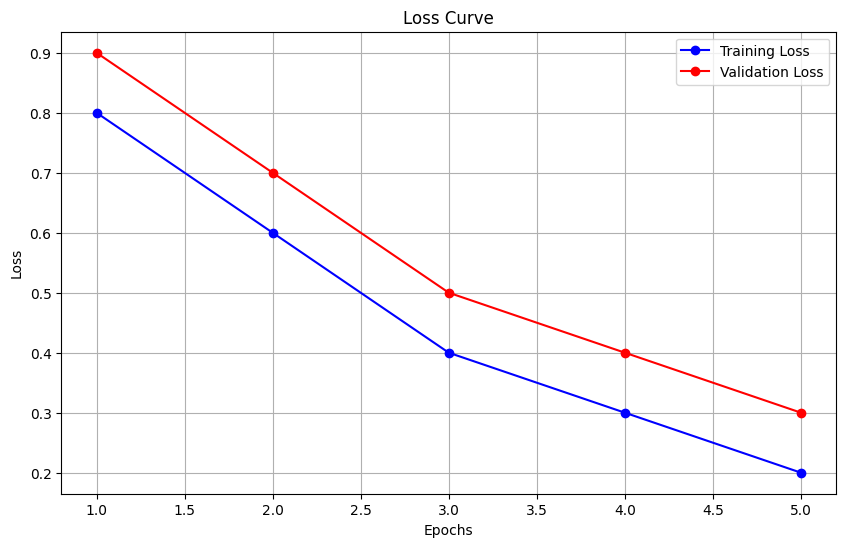

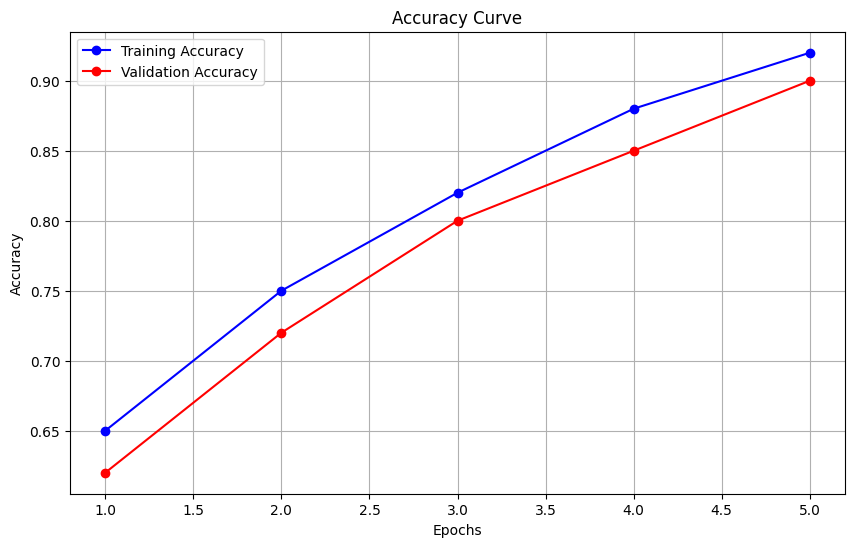

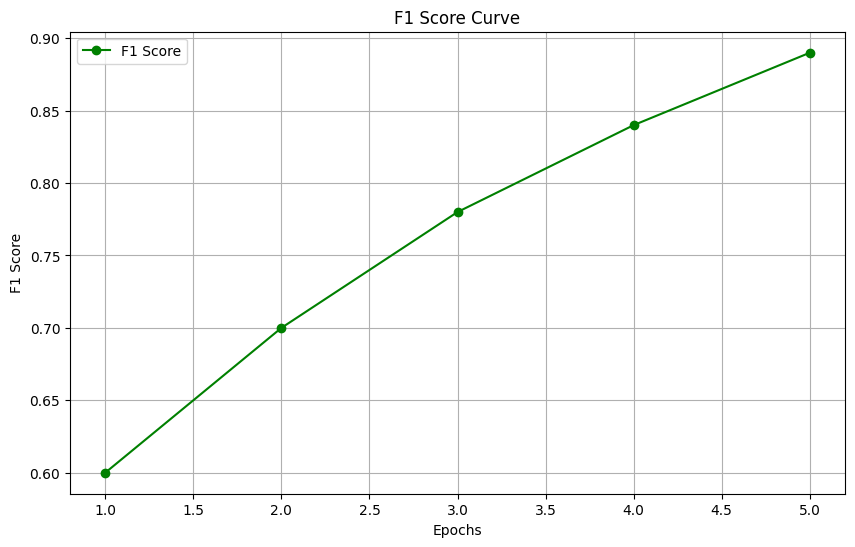

In [29]:
import matplotlib.pyplot as plt

# Sample data for plotting (Replace this with your actual values)
# Example epoch numbers (change as needed)
epochs = range(1, 6)  # Adjust to match the length of your data

# Replace with your actual training losses per epoch
train_losses = [0.8, 0.6, 0.4, 0.3, 0.2]  
# Replace with your validation losses per epoch
val_losses = [0.9, 0.7, 0.5, 0.4, 0.3]  

# Replace with your actual training accuracies
train_accuracies = [0.65, 0.75, 0.82, 0.88, 0.92]  
# Replace with validation accuracies
val_accuracies = [0.62, 0.72, 0.80, 0.85, 0.90]  

# Replace with F1 scores per epoch (optional if you don't need this)
f1_scores = [0.60, 0.70, 0.78, 0.84, 0.89]  

# Plot Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Training Loss', color='blue', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', color='red', marker='o')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Accuracy Curve
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accuracies, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='red', marker='o')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot F1 Score Curve
plt.figure(figsize=(10, 6))
plt.plot(epochs, f1_scores, label='F1 Score', color='green', marker='o')
plt.title('F1 Score Curve')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()